# Data Visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", palette="muted", font_scale=1.2)

## Experimental Data

In [2]:
# ---------------------------
# Load experiment data
# ---------------------------

data = {
    "checkpoint": ["base","16655","33310","49965","66620","83275"]*2,
    "model": ["gpt2_small"]*6 + ["gpt2_large"]*6,
    "self_bleu": [0.476274189,0.657731555,0.66059146,0.605124076,0.62166444,0.612667132,
                  0.493186694,0.534971346,0.593567815,0.578615943,0.58337598,0.588600872],
    "distinct_2": [0.646578538,0.49576351,0.516511766,0.556087824,0.483106106,0.492006395,
                   0.658181112,0.644135189,0.584823285,0.585324948,0.589278264,0.572982016],
    "surprisal_base_model": [2.101585121,2.481666804,2.608512444,2.49778765,2.403695028,2.402671091,
                             1.761671826,3.304129766,3.350486717,3.196896808,3.273157228,3.213343467],
    "fairy_word_score": [3.166666667,3.433333333,3.133333333,3.366666667,2.933333333,3.133333333,
                         4.2,2.2,2.7,2.766666667,2.9,2.633333333],
    "fairy_classifier_mean": [0.606451103,0.864692259,0.842377271,0.854903754,0.869632155,0.85944674,
                              0.789718002,0.760405494,0.818058479,0.830555665,0.839182232,0.835340047],
    "fairy_classifier_std": [0.208291415,0.051841749,0.044251803,0.045268915,0.061651084,0.051051397,
                             0.186840363,0.100036156,0.057821001,0.058561306,0.061340398,0.057567946]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df

,checkpoint,model,self_bleu,distinct_2,surprisal_base_model,fairy_word_score,fairy_classifier_mean,fairy_classifier_std
0,base,gpt2_small,0.476274,0.646579,2.101585,3.166667,0.606451,0.208291
1,16655,gpt2_small,0.657732,0.495764,2.481667,3.433333,0.864692,0.051842
2,33310,gpt2_small,0.660591,0.516512,2.608512,3.133333,0.842377,0.044252
3,49965,gpt2_small,0.605124,0.556088,2.497788,3.366667,0.854904,0.045269
4,66620,gpt2_small,0.621664,0.483106,2.403695,2.933333,0.869632,0.061651
5,83275,gpt2_small,0.612667,0.492006,2.402671,3.133333,0.859447,0.051051
6,base,gpt2_large,0.493187,0.658181,1.761672,4.200000,0.789718,0.186840
7,16655,gpt2_large,0.534971,0.644135,3.304130,2.200000,0.760405,0.100036
8,33310,gpt2_large,0.593568,0.584823,3.350487,2.700000,0.818058,0.057821
9,49965,gpt2_large,0.578616,0.585325,3.196897,2.766667,0.830556,0.058561


## Self-BLEU

Self-BLEU quantifies how similar the generated samples are to each other.  
  - High Self-BLEU  → low diversity (many similar generations)
  - Low Self-BLEU   → high diversity (more varied generations)

**Conclusion**: fine-tuning increases stylistic focus at the cost of diversity to a higher extent for gpt-2-small than for gpt-2-large.

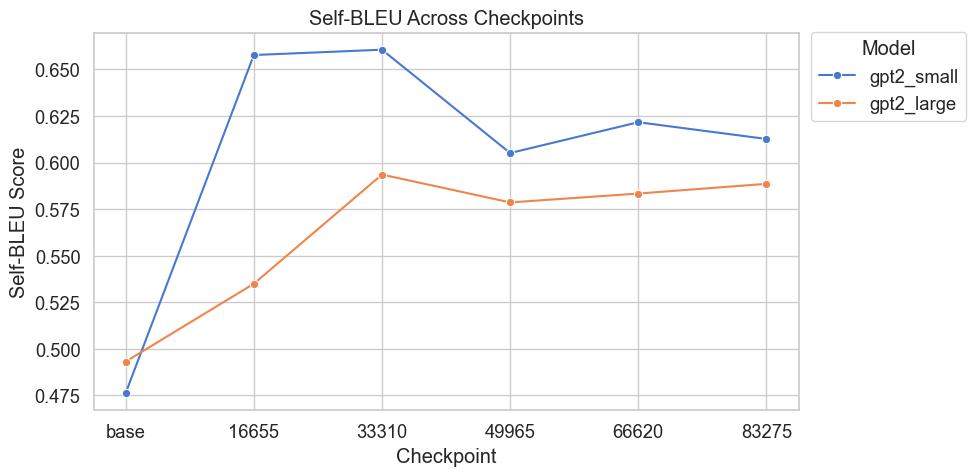

In [5]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="checkpoint", y="self_bleu", hue="model", marker="o")

plt.title("Self-BLEU Across Checkpoints")
plt.ylabel("Self-BLEU Score")
plt.xlabel("Checkpoint")

# Move legend outside top-right
plt.legend(title="Model", loc='upper left', bbox_to_anchor=(1.005, 1.025))
plt.tight_layout()
plt.show()

## Lexical Diversity

Distinct-n is defined as (unique n-grams) / (total n-grams)  

  - Higher Distinct-n → more diverse and less repetitive text
  - Lower Distinct-n  → more repetition / mode collapse  

**Conclusion**: complementary to self-BLEU, fine-tuning increases stylistic focus at the cost of diversity to a higher extent for gpt-2-small than for gpt-2-large.

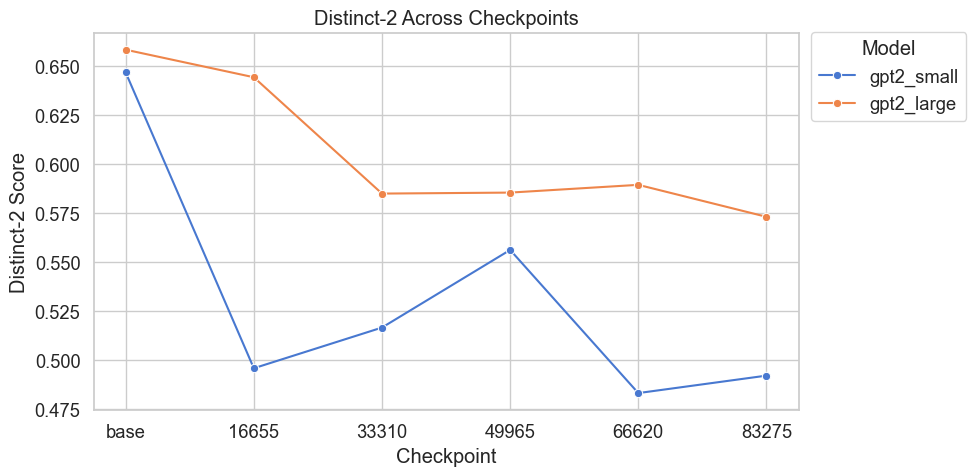

In [6]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="checkpoint", y="distinct_2", hue="model", marker="o")

plt.title("Distinct-2 Across Checkpoints")
plt.ylabel("Distinct-2 Score")
plt.xlabel("Checkpoint")

# Move legend outside top-right
plt.legend(title="Model", loc='upper left', bbox_to_anchor=(1.005, 1.025))
plt.tight_layout()
plt.show()

## Surprisal

Surprisal measures how unexpected a text is according to the model:  
  - Lower surprisal → text is more likely / more familiar to the model
  - Higher surprisal → text is more unexpected  

In this experiment, surprisal is used to evaluate how generated texts
(baseline vs fine-tuned) are perceived by the *base* GPT-2 model.

**Conclusion**: fine-tuning induces a stylistic specialization, making generated texts increasingly fairy-tale-like and less aligned with the base model’s general-language distribution.  
This effect is more pronounced for gpt-2-large than for gpt-2-small.

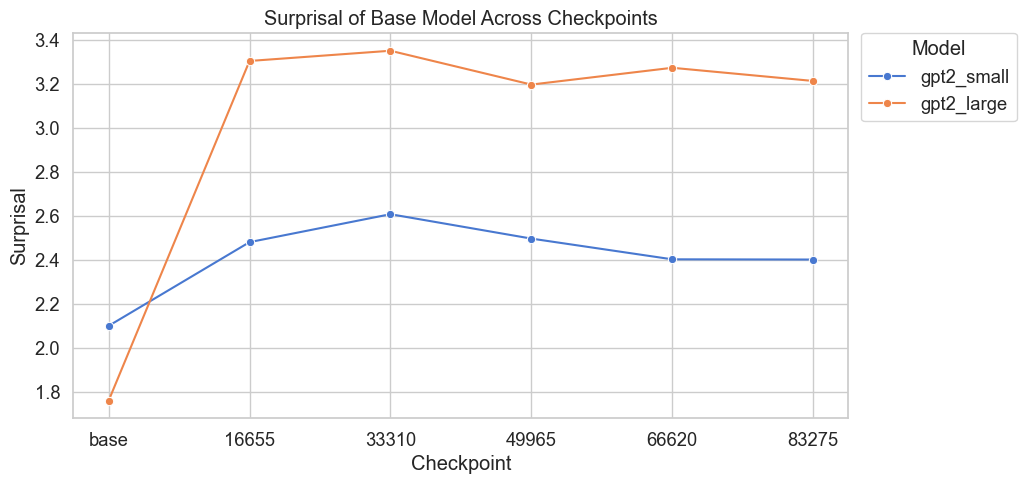

In [7]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="checkpoint", y="surprisal_base_model", hue="model", marker="o")
plt.title("Surprisal of Base Model Across Checkpoints")
plt.ylabel("Surprisal")
plt.xlabel("Checkpoint")
plt.legend(title="Model", loc='upper left', bbox_to_anchor=(1.005, 1.025))
plt.show()

## Fairy Word Score

Counts the number of words in a text that belong to a predefined “fairy tale vocabulary”. For multiple texts, it reports the average number of fairy words per text. Higher scores indicate more fairy-tale–like content.  
**Conclusion**: Fine-tuning nudges gpt-2-small toward a more fairy-tale vocabulary, but the effect is subtle. Gpt-2-large, in contrast, starts with a very high fairy score already. Fine tuning leads to a decreased fairy score, maybe due to the fact that finetuning on a dataset containing less fairy words pushes the model towards a poorer fairy tale performance.   

In [8]:
fairy_words = {
    # Core beings & roles
    "fairy", "fairies", "king", "queen", "prince", "princess",
    "witch", "wizard", "sorcerer", "sorceress", "mage",
    "giant", "ogre", "dragon", "elf", "dwarf", "goblin",
    "knight", "hero", "villain",

    # Magic & supernatural
    "magic", "magical", "spell", "spells", "curse", "cursed",
    "enchantment", "enchanted", "charm", "potion",
    "wand", "crystal", "prophecy", "destiny",

    # Places & settings
    "forest", "woods", "kingdom", "castle", "tower",
    "palace", "village", "cottage", "hut",
    "mountain", "cave", "river", "lake",

    # Objects & symbols
    "crown", "throne", "sword", "shield", "cloak",
    "ring", "mirror", "key", "treasure", "gold",
    "apple", "rose", "needle",

    # Fairy-tale actions & themes
    "wish", "wished", "dream", "dreamed",
    "journey", "quest", "trial",
    "promise", "forbidden",
    "curse", "blessing",
    "transformed", "transformation",

    # Narrative markers
    "once", "kingdom", "ancient", "mystical",
    "legend", "tale", "story", "myth"
}

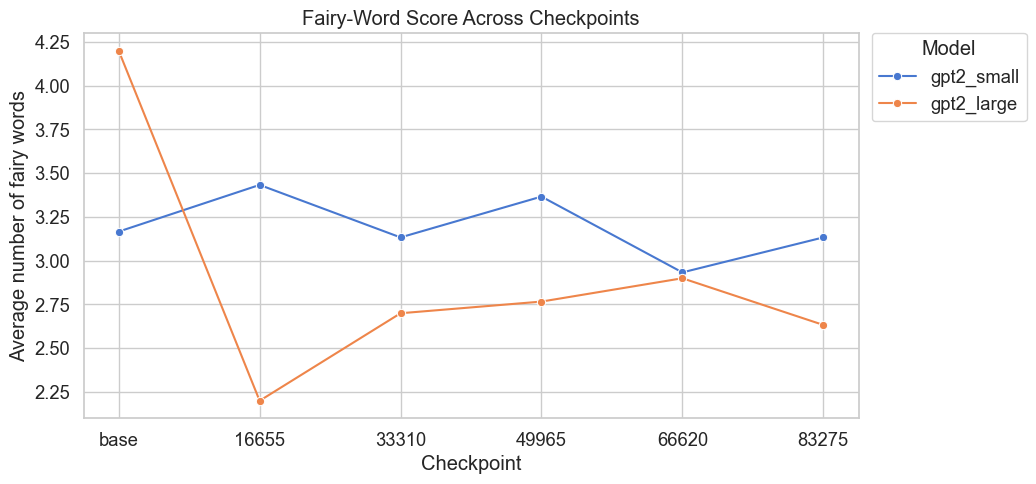

In [9]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="checkpoint", y="fairy_word_score", hue="model", marker="o")
plt.title("Fairy-Word Score Across Checkpoints")
plt.ylabel("Average number of fairy words")
plt.xlabel("Checkpoint")
plt.legend(title="Model", loc='upper left', bbox_to_anchor=(1.005, 1.025))
plt.show()

### Fairy word occurency in data set

In [10]:
from datasets import load_dataset
from collections import Counter
import pandas as pd

# Load the fairy tale dataset from Hugging Face
# This dataset contains fairy tale texts split into train/validation/test
dataset = load_dataset("vicclab/fairy_tales")

# Extract the raw text from the training split
texts = dataset["train"]["text"]

# We use a simple whitespace-based tokenization here
# (lowercasing ensures case-insensitive counting)
all_tokens = []
for text in texts:
    all_tokens.extend(text.lower().split())

# Count how often each token appears in the dataset
token_counts = Counter(all_tokens)

# For each word in the fairy_words list, retrieve its frequency
# Only include words that actually appear in the dataset
fairy_word_counts = {
    word: token_counts[word]
    for word in fairy_words
    if word in token_counts
}

# Convert to DataFrame
df_fairy_words = (
    pd.DataFrame(
        fairy_word_counts.items(),
        columns=["fairy_word", "count"]
    )
    .sort_values("count", ascending=False)
)


C:\Users\micha\anaconda3\envs\transformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


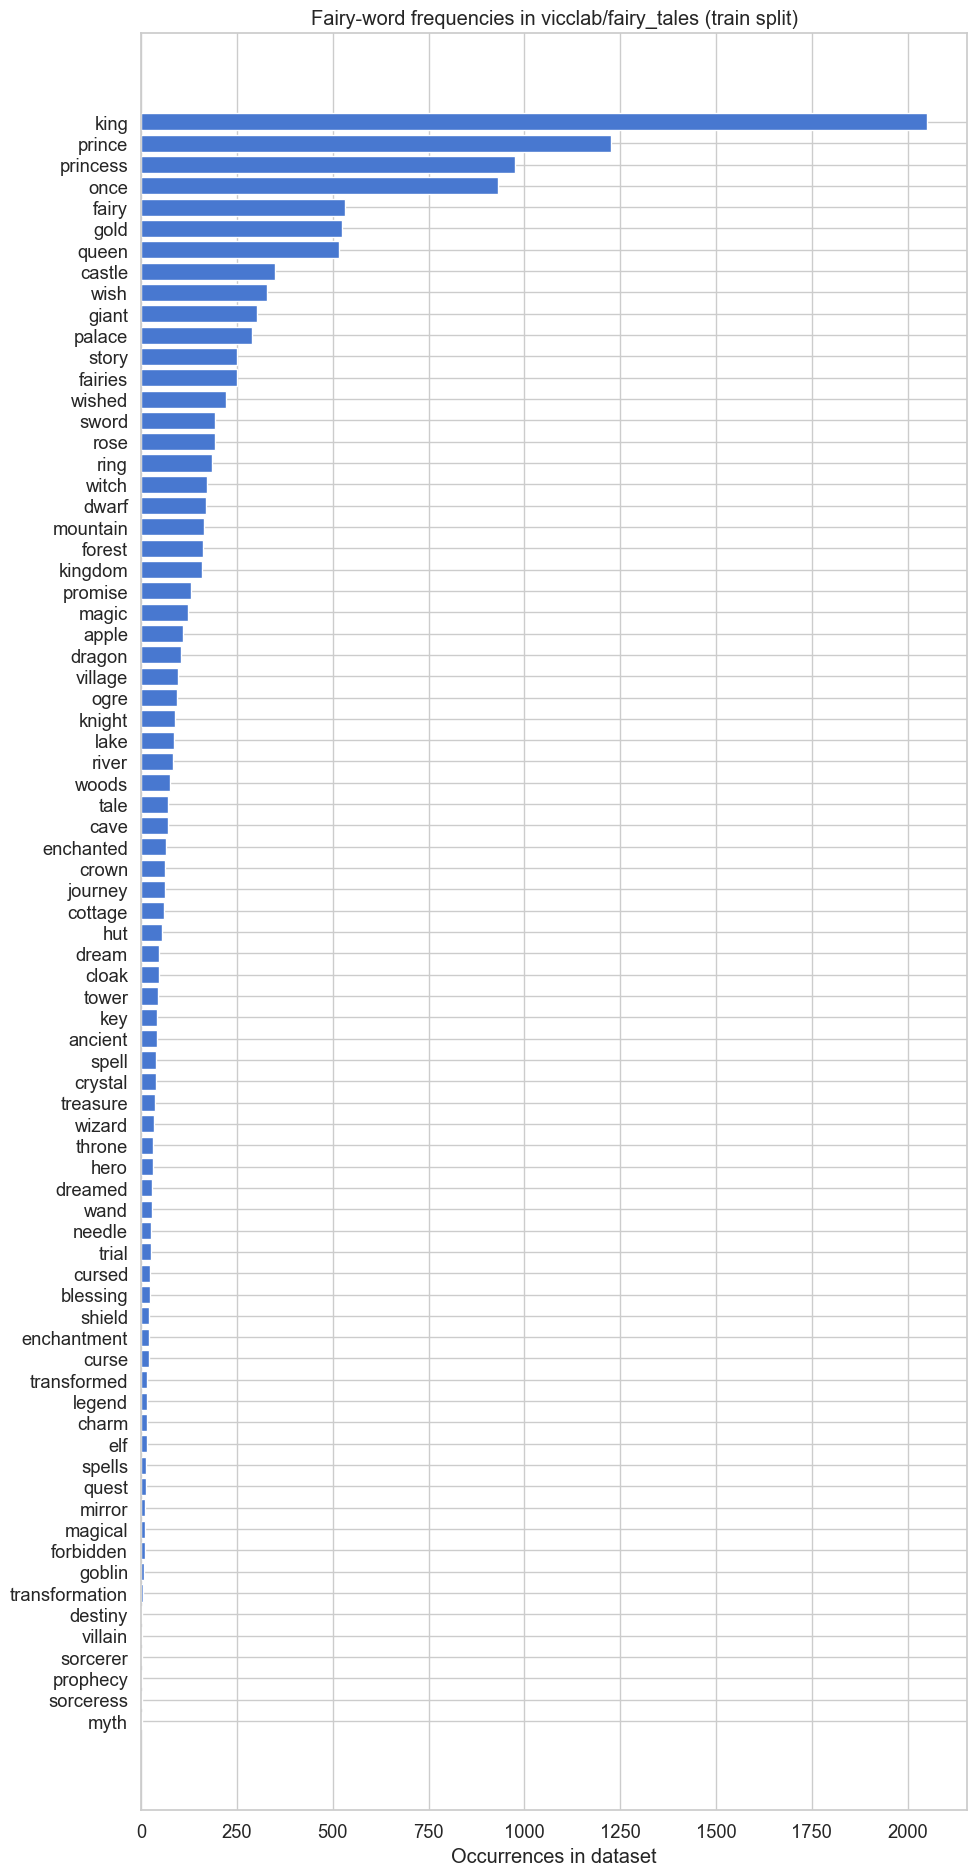

In [11]:
plt.figure(figsize=(10, max(4, len(df_fairy_words) * 0.25)))
plt.barh(df_fairy_words["fairy_word"], df_fairy_words["count"])
plt.xlabel("Occurrences in dataset")
plt.title("Fairy-word frequencies in vicclab/fairy_tales (train split)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
coverage = len(df_fairy_words) / len(fairy_words)
print(f"Fairy-word vocabulary coverage: {coverage:.2%}")

Fairy-word vocabulary coverage: 96.20%


---

## Fairy Classifier

  - Input: a generated text (or list of texts)
  - Candidate labels: e.g., ["fairy tale", "non-fairy tale"]
  - Output: probability/confidence that the text is a fairy tale

**bart-large-mnli**:  
  - allows zero-shot classification without fine-tuning
  - is large enough to understand nuanced stylistic cues and therefore detect stylistic differences
  - is robust and widely used 

**bart-large-mnli**:  
  - a sequence-to-sequence transformer model (BART) fine-tuned on MNLI (Multi-Genre Natural Language Inference)
  - takes a premise and a hypothesis and predicts whether the premise entails, contradicts, or is neutral with respect to the hypothesis  
  - allows zero-shot classification without fine-tuning
  - is large enough to understand nuanced stylistic cues and therefore detect stylistic differences
  - is robust and widely used 

**Conclusion**: the zero-shot classifier confirms that fine-tuning shifts both gpt-2-small and gpt-2-large toward a fairy tale style, with the effect being more pronounced for gpt-2-small.

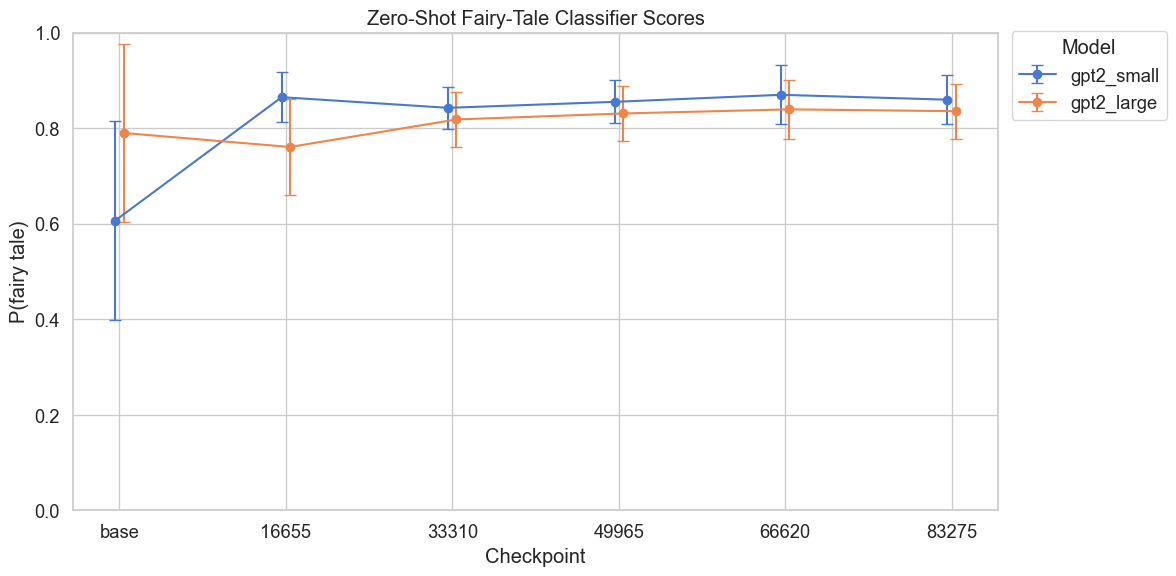

In [13]:
plt.figure(figsize=(12,6))

offset = 0.05  # adjust as needed
for i, model in enumerate(df['model'].unique()):
    subset = df[df['model']==model]
    x = np.arange(len(subset)) + (i - 0.5) * offset  # shift each model slightly
    plt.errorbar(x, subset['fairy_classifier_mean'], 
                 yerr=subset['fairy_classifier_std'], 
                 marker='o', label=model, capsize=4)

plt.title("Zero-Shot Fairy-Tale Classifier Scores")
plt.ylabel("P(fairy tale)")
plt.xlabel("Checkpoint")
plt.xticks(np.arange(len(subset)), subset['checkpoint'])  # restore original x labels
plt.ylim(0,1)
plt.legend(title="Model", loc='upper left', bbox_to_anchor=(1.005, 1.022))
plt.tight_layout()
plt.show()